<a href="https://colab.research.google.com/github/Lorenzito/ProgramacionParaAnaliticaDescriptivayPredicitva/blob/main/Sesion12_Evaluacion_Analisis_273524.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Lorenzo Varela Ollervides
- **Matrícula:** 273524

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [17]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
Media = df['price'].mean()
Mediana = df['price'].median()
Moda = df['price'].mode()

print(f'Media: {Media:,.2f}')
print(f'Mediana: {Mediana:,.2f}')
print(f'Moda: {Moda}')

# Revisamos el mínimo y el máximo para confirmar de dónde sale el rango
print(df['price'].agg(['min', 'max']))

Media: 152.72
Mediana: 106.00
Moda: 0    100
Name: price, dtype: int64
min        0
max    10000
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ Divergen casi por ~47 unidades, considerando que son valores pequeños es una divergencia grande, esto nos indica que debe de haber presencia de valores extremos o asimetría.

---
## Actividad 2 — Dispersión (20 pts)

In [18]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

rango = df['price'].max() - df['price'].min()
varianza = df['price'].var()
desviacion = df['price'].std()

print(f'Rango:               {rango:,.2f}')
print(f'Varianza:            {varianza:,.2f}')
print(f'Desviación estándar: {desviacion:,.2f}')

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1 (percentil 25):   {Q1:,.2f}')
print(f'Q3 (percentil 75):   {Q3:,.2f}')
print(f'IQR:                 {IQR:,.2f}')


Rango:               10,000.00
Varianza:            57,674.03
Desviación estándar: 240.15
Q1 (percentil 25):   69.00
Q3 (percentil 75):   175.00
IQR:                 106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ Rango 10,000 contra IQR 106. El IQR me parece una representación más robusta de la dispersión típica de los datos porque no se ve influenciado por valores atípicos, ignora por diseño el 25% más bajo y el 25% más alto.

---
## Actividad 3 — Forma (20 pts)

In [19]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print(f'Asimetría: {df["price"].skew():,.2f}')
print(f'Curtosis:  {df["price"].kurt():,.2f}')



Asimetría: 19.12
Curtosis:  585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ Para price una asimetría mayor a 0 nos esta indicando que la distribución de los valores se inclina a la derecha y al ser la curtosis un valor tan alto quiere decir que hay valores muy alejados del centro. Estos valores anticipan muchos outliers extremos, que se tratarán en la siguiente etapa de Datos Atípicos.


---
## Actividad 4 — Visualización (30 pts)

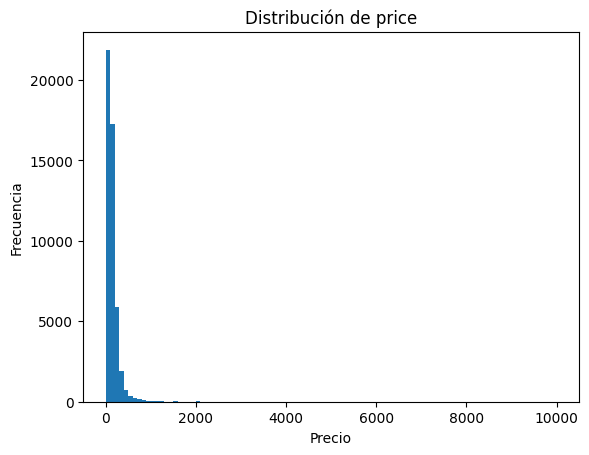

In [20]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

# Usamos bins=100 para tener un nivel de detalle suficiente; con un rango de 0 a 10,000 cada bin abarca aproximadamente $100.
df['price'].plot(kind='hist', bins=100, title="Distribución de price")
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()



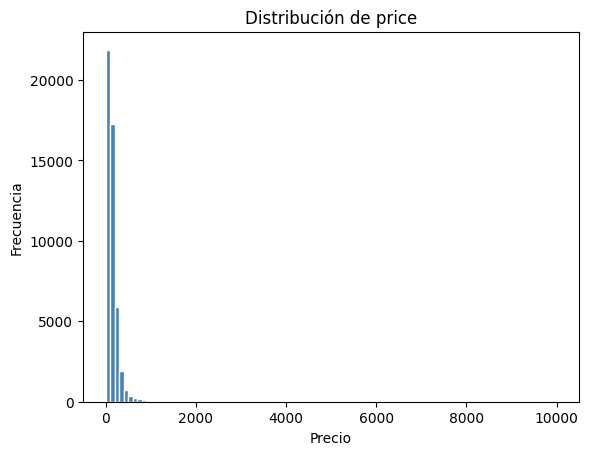

In [21]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df['price'], bins=100, color='steelblue', edgecolor='white') # 4.2 — Mismo histograma con plt.hist(); mantenemos bins=100 para que sea comparable con el de 4.1
plt.title('Distribución de price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


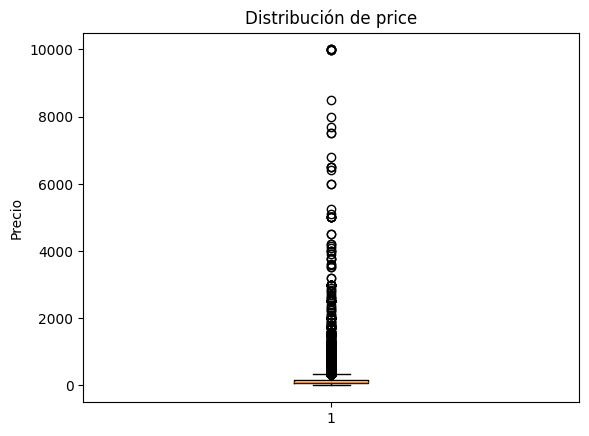

In [22]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

# Usamos un boxplot porque muestra los outliers como puntos individuales (fuera de los bigotes),
# lo que permite ver los valores extremos que el histograma no distingue bien.
plt.boxplot(df['price'])
plt.title('Distribución de price')
plt.ylabel('Precio')
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_
En el histograma se observa que casi todos los registros se concentran en las primeras barras, a la izquierda, con precios bajos (unos cientos de dólares), y luego hay una cola muy larga que se extiende hasta los 10,000. Esa cola apenas se ve porque las frecuencias son tan pequeñas que las barras casi no se distinguen. En el boxplot, la caja (Q1 = 69 a Q3 = 175) queda muy pequeña y pegada al fondo, y por encima de los bigotes aparecen muchísimos puntos aislados, algunos llegando hasta 10,000.

Los outliers sí se ven en ambos gráficos, pero se distinguen mejor en el boxplot, porque cada valor extremo aparece como un punto individual. En el histograma solo se infieren por la cola alargada, y las barras de esa zona son casi invisibles.

Esto coincide con los estadísticos de la Actividad 3. La asimetría de 19.12 (positiva y muy alta) confirma la cola hacia la derecha que se ve en el histograma, y la curtosis de 585.67 confirma que hay valores extremadamente alejados del centro, que son los puntos del boxplot. También coincide con que la media (152.72) sea mayor que la mediana (106): los outliers de la derecha jalan el promedio hacia arriba.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_
El precio promedio de 152.72 puede ser engañoso porque no representa lo que paga un listado típico. La mediana es de 106, así que la mitad de los listados cuesta menos que eso, y la media queda unos 47 por encima. Esa diferencia se debe a un grupo pequeño de listados con precios muy altos, que jalan el promedio hacia arriba. Con un promedio de 152.72, alguien podría esperar pagar eso por un hospedaje común, cuando en realidad más de la mitad cuesta menos.

El resto de las medidas confirma esto. El rango es de 10,000, pero el IQR es de solo 106 (Q1 = 69, Q3 = 175). Es decir, la mayor parte de los precios se concentra en un intervalo estrecho, y unos pocos valores extremos son los que alargan el rango. Además, la desviación estándar (240.15) es mayor que la propia media, lo que también indica que unos cuantos valores extremos inflan la dispersión.

Por eso, para describir el precio típico en este dataset es más confiable la mediana y el IQR que la media y el rango.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |